In [1]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt

df = sns.load_dataset('titanic')
df.to_csv('../data/titanic.csv', index=False)

Посчитаю разницу доли выживших по полу

In [2]:
s_main = df[df['sex'] == 'female']['survived'].mean() - df[df['sex'] == 'male']['survived'].mean()
print(s_main)

0.5531300709799203


Сделаю перемешаю полы в выборке и посчитаю разницу снова

Думаю раз перемешается случайно, то разница будет примерно 0

In [3]:
sex_values = df['sex'].values
df['sex'] = np.random.permutation(sex_values)
print(df[df['sex'] == 'female']['survived'].mean() - df[df['sex'] == 'male']['survived'].mean())

0.022005983066376744


Результат получился около нуля так как при перемешивание у мужчины попасть в ячейку выжившего столько же шанса как и у женщины

Повторю это 10000 раз и построю гистограмму

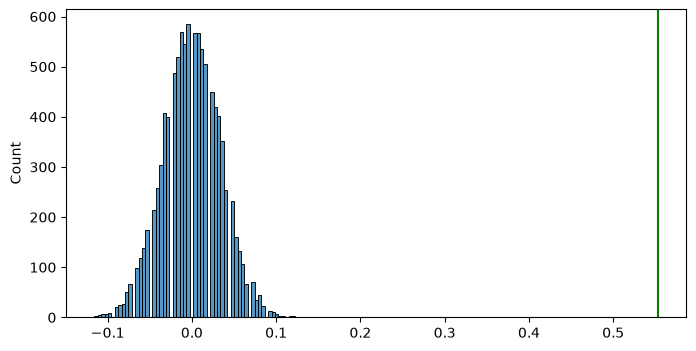

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
lines = []
survived_values = df['survived'].values

for _ in range(10000):
    shuffled_sex = np.random.permutation(sex_values)
    s = survived_values[shuffled_sex == 'female'].mean() - survived_values[shuffled_sex == 'male'].mean()
    lines.append(s)

sns.histplot(data=lines, ax=ax)
ax.axvline(x=s_main, color='green')

Посчитаю долю разницы средний тех, что по модулю не меньше оригинальной, хотя по картинке видно что это ноль, но всё же сверюсь по числам

In [5]:
print(sum(1 for x in lines if abs(x) >= s_main) / 10000)

0.0


p получилось меньше 0.0001, значит можно опровергнуть гипотезу о том что пол не влияет на выживаемость

Теперь посчитаю то же самое только для чётности индексов

In [6]:
y_main = df.iloc[::2]['survived'].mean() - df.iloc[1::2]['survived'].mean()
print(y_main)

-0.05922305638131703


получилось почти ноль

теперь посчитаю это 10000 и построю гистограмму думаю p получится большим, а как гистограмма будет выглядеть я не могу представить

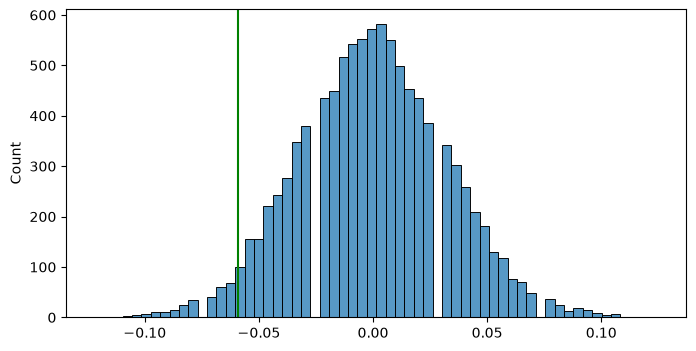

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
lines = []

for _ in range(10000):
    shuffled_survived = df['survived'].sample(frac=1).reset_index(drop=True)
    diff = shuffled_survived.iloc[::2].mean() - shuffled_survived.iloc[1::2].mean()
    lines.append(diff)

sns.histplot(data=lines, ax=ax)
ax.axvline(x=y_main, color='green')

In [8]:
print(sum(1 for x in lines if abs(x) >= abs(y_main)) / 10000)

0.0706


здесь p больше 0.05, что не позволяет нам отвергнуть нулевую гипотезу о том что индекс не влияет на выживаемость